# EfficientNetV2B0 — Optimized Transfer Learning Notebook


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install scikit-learn opencv-python-headless

In [3]:
import os
import gc
import json
import math
import glob
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

mixed_precision.set_global_policy("mixed_float16")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DRIVE_ROOT = Path("/content/drive/MyDrive/Skin Disease Detection")
DRIVE_DATA_DIR = DRIVE_ROOT / "skin-data"
LOCAL_DATA_DIR = Path("/content/skin-data")
OUTPUT_DIR = DRIVE_ROOT / "outputs_effnetv2b0_opt8"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_PHASE1 = 12
EPOCHS_PHASE2 = 12
EPOCHS_PHASE3 = 18

RESET_LOCAL_COPY = True       # đổi False nếu muốn giữ local copy cũ
USE_FOCAL_LOSS = True         # True khuyên dùng cho dataset lệch class
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Kiểm tra dữ liệu trên Drive

In [4]:
assert DRIVE_DATA_DIR.exists(), f"Không tìm thấy {DRIVE_DATA_DIR}"

for split in ["train", "val", "test"]:
    split_dir = DRIVE_DATA_DIR / split
    assert split_dir.exists(), f"Không tìm thấy {split_dir}"
    classes = sorted([x.name for x in split_dir.iterdir() if x.is_dir()])
    print(split, len(classes), classes)

train 8 ['acne_rosacea', 'atopic_dermatitis', 'bullous_disease', 'eczema', 'nail_fungus', 'tinea', 'vitiligo', 'warts']
val 8 ['acne_rosacea', 'atopic_dermatitis', 'bullous_disease', 'eczema', 'nail_fungus', 'tinea', 'vitiligo', 'warts']
test 8 ['acne_rosacea', 'atopic_dermatitis', 'bullous_disease', 'eczema', 'nail_fungus', 'tinea', 'vitiligo', 'warts']


## 2. Reset local copy và copy data từ Drive về local

Nếu bạn vừa đổi số class, nên để `RESET_LOCAL_COPY = True`.

In [5]:
if RESET_LOCAL_COPY and LOCAL_DATA_DIR.exists():
    shutil.rmtree(LOCAL_DATA_DIR)
    print("Đã xóa local skin-data cũ")

if not LOCAL_DATA_DIR.exists():
    print("Đang copy dữ liệu từ Drive về local...")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Copy xong.")
else:
    print("Local data đã tồn tại, bỏ qua copy.")

TRAIN_DIR = LOCAL_DATA_DIR / "train"
VAL_DIR   = LOCAL_DATA_DIR / "val"
TEST_DIR  = LOCAL_DATA_DIR / "test"

Đang copy dữ liệu từ Drive về local...
Copy xong.


## 3. Đọc class và thống kê dữ liệu

In [6]:
CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print("NUM_CLASSES =", NUM_CLASSES)
print(CLASS_NAMES)

def count_images(folder, class_names):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    rows = []
    for cls in class_names:
        n = sum(1 for f in (folder / cls).iterdir() if f.suffix.lower() in exts)
        rows.append({"class_name": cls, "count": n})
    return pd.DataFrame(rows)

train_df = count_images(TRAIN_DIR, CLASS_NAMES).rename(columns={"count": "train"})
val_df   = count_images(VAL_DIR, CLASS_NAMES).rename(columns={"count": "val"})
test_df  = count_images(TEST_DIR, CLASS_NAMES).rename(columns={"count": "test"})

stats_df = train_df.merge(val_df, on="class_name").merge(test_df, on="class_name")
stats_df["total"] = stats_df["train"] + stats_df["val"] + stats_df["test"]
display(stats_df.sort_values("total", ascending=False))

with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, indent=2, ensure_ascii=False)

NUM_CLASSES = 8
['acne_rosacea', 'atopic_dermatitis', 'bullous_disease', 'eczema', 'nail_fungus', 'tinea', 'vitiligo', 'warts']


,class_name,train,val,test,total
5,tinea,1605,344,345,2294
3,eczema,1251,268,269,1788
1,atopic_dermatitis,842,180,181,1203
0,acne_rosacea,773,165,167,1105
7,warts,760,162,164,1086
6,vitiligo,718,153,155,1026
4,nail_fungus,600,128,130,858
2,bullous_disease,313,67,68,448


## 4. Tạo dataset

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 6862 files belonging to 8 classes.
Found 1467 files belonging to 8 classes.
Found 1479 files belonging to 8 classes.


## 5. Class weights

In [8]:
y_train = []
train_for_weights = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
for _, labels in train_for_weights:
    y_train.extend(labels.numpy().tolist())

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=np.array(y_train)
)
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(weights)}

for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:<24s}: {CLASS_WEIGHT[i]:.3f}")

Found 6862 files belonging to 8 classes.
acne_rosacea            : 1.110
atopic_dermatitis       : 1.019
bullous_disease         : 2.740
eczema                  : 0.686
nail_fungus             : 1.430
tinea                   : 0.534
vitiligo                : 1.195
warts                   : 1.129


## 6. Focal Loss

In [9]:
class SparseCategoricalFocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, name="sparse_categorical_focal_loss"):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        ce = -y_true_one_hot * tf.math.log(y_pred)
        p_t = y_true_one_hot * y_pred
        focal = self.alpha * tf.pow(1.0 - p_t, self.gamma) * ce
        return tf.reduce_sum(focal, axis=-1)

    def get_config(self):
        return {"gamma": self.gamma, "alpha": self.alpha}

## 7. Data augmentation

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
], name="augmentation")

## 8. Build model — EfficientNetV2B0

In [11]:
def build_model(num_classes):
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="image")
    x = data_augmentation(inputs)
    x = layers.Activation("linear", dtype="float32", name="cast_to_float32")(x)
    x = preprocess_input(x)

    backbone = tf.keras.applications.EfficientNetV2B0(include_top=False, weights="imagenet", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Dropout(0.45, name="dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.35, name="dropout_2")(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    model = keras.Model(inputs, outputs, name="EfficientNetV2B0")
    return model, backbone

model, backbone = build_model(NUM_CLASSES)
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetV2B0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_to_float32 (Activation)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,254,424 (23.86 MB)

 Trainable params: 332,552 (1.27 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

## 9. Compile / callbacks / unfreeze helpers

In [12]:
def compile_model(model, lr):
    loss_fn = SparseCategoricalFocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA) if USE_FOCAL_LOSS else "sparse_categorical_crossentropy"
    optimizer = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=["accuracy"]
    )

def make_callbacks(tag):
    return [
        keras.callbacks.ModelCheckpoint(
            OUTPUT_DIR / f"{tag}.keras",
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            mode="max",
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

def set_trainable_ratio(backbone, ratio):
    backbone.trainable = True
    n = len(backbone.layers)
    start = int(n * (1 - ratio))
    for layer in backbone.layers[:start]:
        layer.trainable = False
    for layer in backbone.layers[start:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    trainable = sum(int(layer.trainable) for layer in backbone.layers)
    print(f"Backbone trainable layers: {trainable}/{n}")

## 10. Train — Phase 1

In [13]:
compile_model(model, lr=1e-3)
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks("best_phase1"),
    verbose=1,
)

Epoch 1/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3503 - loss: 0.4873
Epoch 1: val_accuracy improved from None to 0.53033, saving model to /content/drive/MyDrive/Skin Disease Detection/outputs_effnetv2b0_opt8/best_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skin Disease Detection/outputs_effnetv2b0_opt8/best_phase1.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 77s 205ms/step - accuracy: 0.4070 - loss: 0.4082 - val_accuracy: 0.5303 - val_loss: 0.2105 - learning_rate: 0.0010
Epoch 2/12
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4864 - loss: 0.2996
Epoch 2: val_accuracy improved from 0.53033 to 0.56919, saving model to /content/drive/MyDrive/Skin Disease Detection/outputs_effnetv2b0_opt8/best_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Skin Disease Detection/outputs_effnetv2b0_opt8/best_phase1.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 104ms/step - accuracy: 0.4920 - loss: 0.2835 - val_accuracy: 0.5692 - val_loss: 0.203

## 11. Train — Phase 2

In [14]:
set_trainable_ratio(backbone, ratio=0.45)
compile_model(model, lr=1e-4)
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks("best_phase2"),
    verbose=1,
)

Backbone trainable layers: 97/270
Epoch 1/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6511 - loss: 0.1261
Epoch 1: val_accuracy improved from None to 0.64622, saving model to /content/drive/MyDrive/Skin Disease Detection/outputs_effnetv2b0_opt8/best_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skin Disease Detection/outputs_effnetv2b0_opt8/best_phase2.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 72s 181ms/step - accuracy: 0.6594 - loss: 0.1240 - val_accuracy: 0.6462 - val_loss: 0.1348 - learning_rate: 1.0000e-04
Epoch 2/12
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6773 - loss: 0.1102
Epoch 2: val_accuracy did not improve from 0.64622
215/215 ━━━━━━━━━━━━━━━━━━━━ 29s 136ms/step - accuracy: 0.6839 - loss: 0.1066 - val_accuracy: 0.6455 - val_loss: 0.1401 - learning_rate: 1.0000e-04
Epoch 3/12
214/215 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6949 - loss: 0.1044
Epoch 3: val_accuracy improved from 0.64622 to 0.66394, saving model to /co

## 12. Train — Phase 3

In [15]:
set_trainable_ratio(backbone, ratio=0.80)
compile_model(model, lr=5e-5)
history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE3,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks("best_final"),
    verbose=1,
)

histories = {
    "phase1": history1.history,
    "phase2": history2.history,
    "phase3": history3.history,
}

with open(OUTPUT_DIR / "history.json", "w", encoding="utf-8") as f:
    json.dump(histories, f, indent=2)

Backbone trainable layers: 173/270
Epoch 1/18
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7947 - loss: 0.0595
Epoch 1: val_accuracy improved from None to 0.72870, saving model to /content/drive/MyDrive/Skin Disease Detection/outputs_effnetv2b0_opt8/best_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skin Disease Detection/outputs_effnetv2b0_opt8/best_final.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 99s 239ms/step - accuracy: 0.7935 - loss: 0.0585 - val_accuracy: 0.7287 - val_loss: 0.1118 - learning_rate: 5.0000e-05
Epoch 2/18
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8079 - loss: 0.0563
Epoch 2: val_accuracy did not improve from 0.72870
215/215 ━━━━━━━━━━━━━━━━━━━━ 50s 155ms/step - accuracy: 0.8071 - loss: 0.0562 - val_accuracy: 0.7137 - val_loss: 0.1218 - learning_rate: 5.0000e-05
Epoch 3/18
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8048 - loss: 0.0548
Epoch 3: val_accuracy improved from 0.72870 to 0.73551, saving model to /con

## 13. Vẽ learning curves

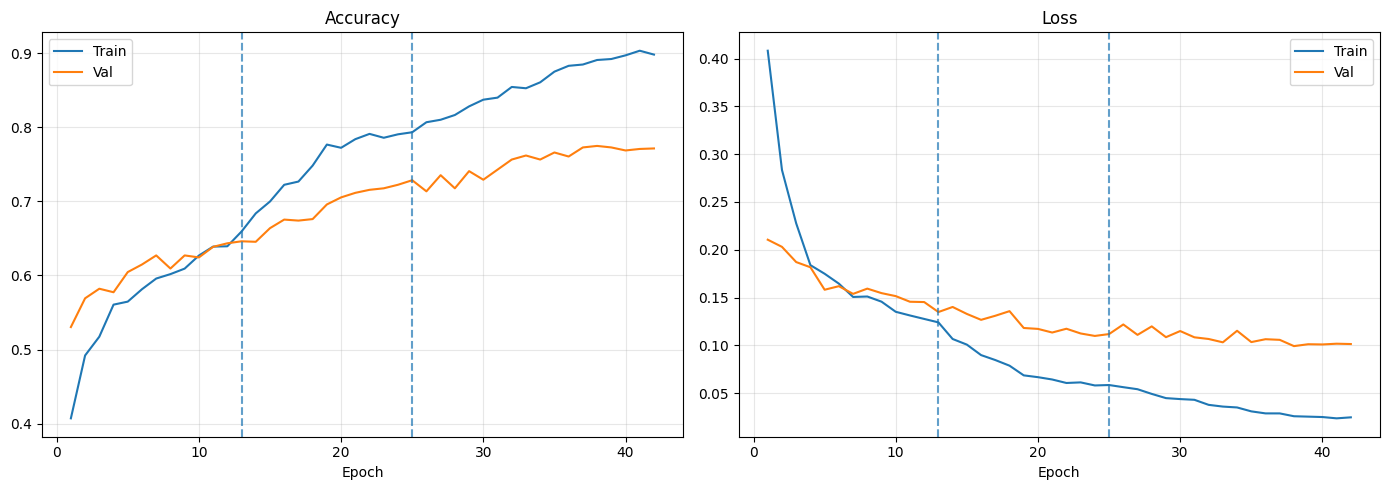

In [16]:
acc = histories["phase1"]["accuracy"] + histories["phase2"]["accuracy"] + histories["phase3"]["accuracy"]
val_acc = histories["phase1"]["val_accuracy"] + histories["phase2"]["val_accuracy"] + histories["phase3"]["val_accuracy"]
loss = histories["phase1"]["loss"] + histories["phase2"]["loss"] + histories["phase3"]["loss"]
val_loss = histories["phase1"]["val_loss"] + histories["phase2"]["val_loss"] + histories["phase3"]["val_loss"]

x = range(1, len(acc) + 1)
p2_start = len(histories["phase1"]["accuracy"]) + 1
p3_start = p2_start + len(histories["phase2"]["accuracy"])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(x, acc, label="Train")
plt.plot(x, val_acc, label="Val")
plt.axvline(p2_start, linestyle="--", alpha=0.7)
plt.axvline(p3_start, linestyle="--", alpha=0.7)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, loss, label="Train")
plt.plot(x, val_loss, label="Val")
plt.axvline(p2_start, linestyle="--", alpha=0.7)
plt.axvline(p3_start, linestyle="--", alpha=0.7)
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=180)
plt.show()

## 14. Load best model để đánh giá

In [17]:
custom_objects = {
    "SparseCategoricalFocalLoss": SparseCategoricalFocalLoss,
}

best_model = keras.models.load_model(
    OUTPUT_DIR / "best_final.keras",
    custom_objects=custom_objects
)

## 15. Đánh giá trên test set

In [18]:
y_true, y_pred, y_prob = [], [], []
for images, labels in test_ds:
    probs = best_model(images, training=False).numpy()
    preds = np.argmax(probs, axis=1)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(preds.tolist())
    y_prob.extend(probs.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"Macro F1      : {macro_f1:.4f}")
print(f"Weighted F1   : {weighted_f1:.4f}")

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True)
report_df = pd.DataFrame(report).T
display(report_df)
report_df.to_csv(OUTPUT_DIR / "classification_report.csv", encoding="utf-8-sig")

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump({
        "test_accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
    }, f, indent=2)

Test Accuracy : 0.7857 (78.57%)
Macro F1      : 0.7826
Weighted F1   : 0.7871


,precision,recall,f1-score,support
acne_rosacea,0.831250,0.796407,0.813456,167.000000
atopic_dermatitis,0.706215,0.690608,0.698324,181.000000
bullous_disease,0.516854,0.676471,0.585987,68.000000
eczema,0.778226,0.717472,0.746615,269.000000
nail_fungus,0.902098,0.992308,0.945055,130.000000
tinea,0.815047,0.753623,0.783133,345.000000
vitiligo,0.986395,0.935484,0.960265,155.000000
warts,0.668367,0.798780,0.727778,164.000000
accuracy,0.785666,0.785666,0.785666,0.785666
macro avg,0.775556,0.795144,0.782577,1479.000000


## 16. Confusion matrix

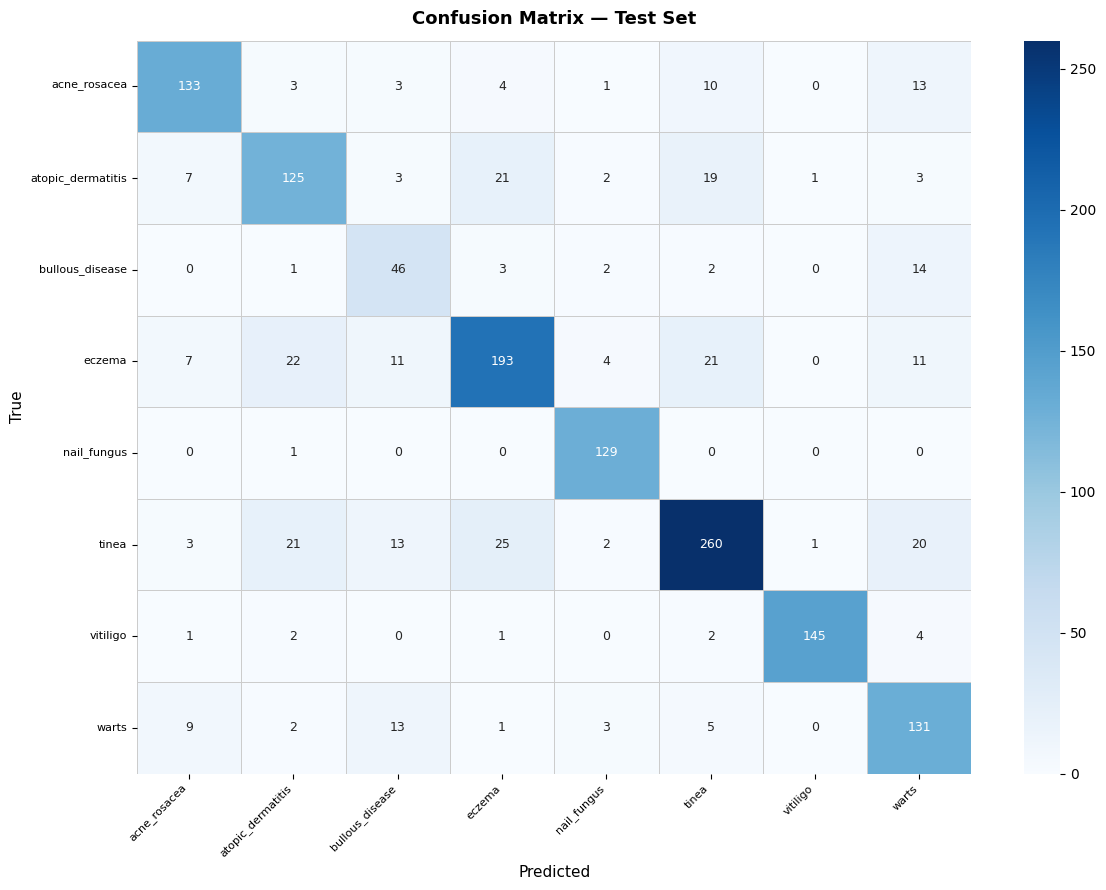

In [30]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.4,
    linecolor="#cccccc",
    annot_kws={"size": 9},
)
plt.title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("True", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

## 17. Grad-CAM

In [37]:
def make_gradcam_heatmap(img_array, model, pred_index=None):
    # Output của backbone call = input của layer "gap"
    gap_layer = model.get_layer("gap")
    conv_output_tensor = gap_layer.input  # tensor (batch, H, W, C) trong graph của model

    grad_model = keras.Model(
        inputs=model.input,
        outputs=[conv_output_tensor, model.output],
    )

    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    if grads is None:
        raise ValueError("Gradient is None. Run tf.config.run_functions_eagerly(True) first.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs_np = conv_outputs[0].numpy()
    pooled_grads_np = pooled_grads.numpy()

    heatmap = np.sum(conv_outputs_np * pooled_grads_np, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    return heatmap


def show_gradcam(image_path, model):
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img).astype("float32")
    input_array = np.expand_dims(img_array, axis=0)

    preds = model(input_array, training=False).numpy()[0]
    pred_idx = int(np.argmax(preds))
    pred_name = CLASS_NAMES[pred_idx]
    conf = preds[pred_idx]

    heatmap = make_gradcam_heatmap(input_array, model, pred_idx)
    heatmap_resized = cv2.resize(heatmap.astype("float32"), IMG_SIZE)

    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = np.clip(np.uint8(0.45 * heatmap_color + 0.55 * img_array), 0, 255)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(np.uint8(img_array)); axes[0].axis("off"); axes[0].set_title("Original")
    axes[1].imshow(heatmap_resized, cmap="jet"); axes[1].axis("off"); axes[1].set_title("Heatmap")
    axes[2].imshow(overlay); axes[2].axis("off"); axes[2].set_title(f"{pred_name}\n{conf*100:.1f}%")
    plt.tight_layout()
    plt.show()

/content/skin-data/test/tinea/tinea_00339.jpg


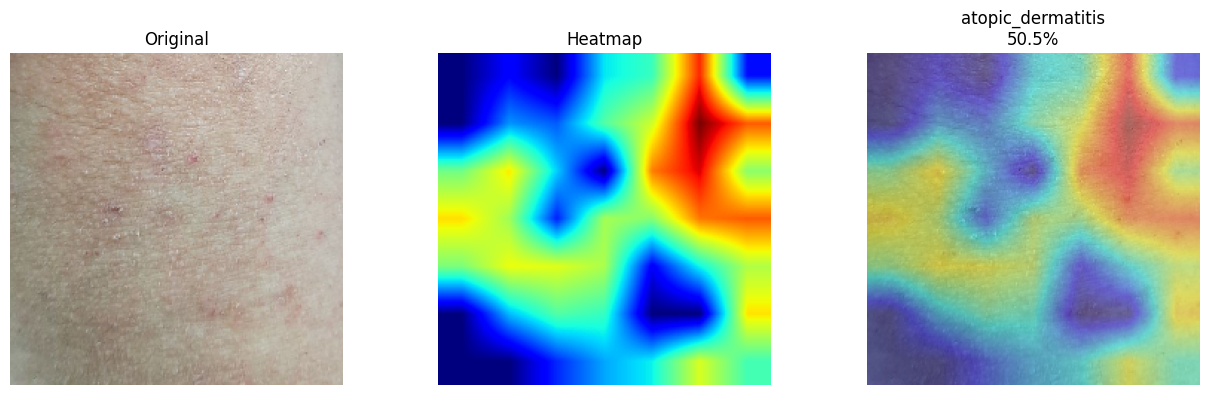

/content/skin-data/test/warts/warts_00019.jpg


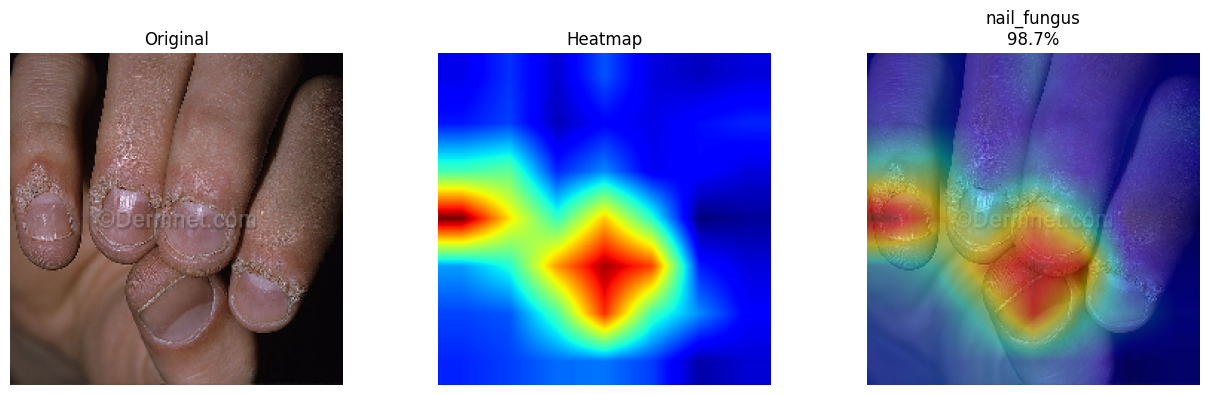

/content/skin-data/test/tinea/tinea_00256.jpeg


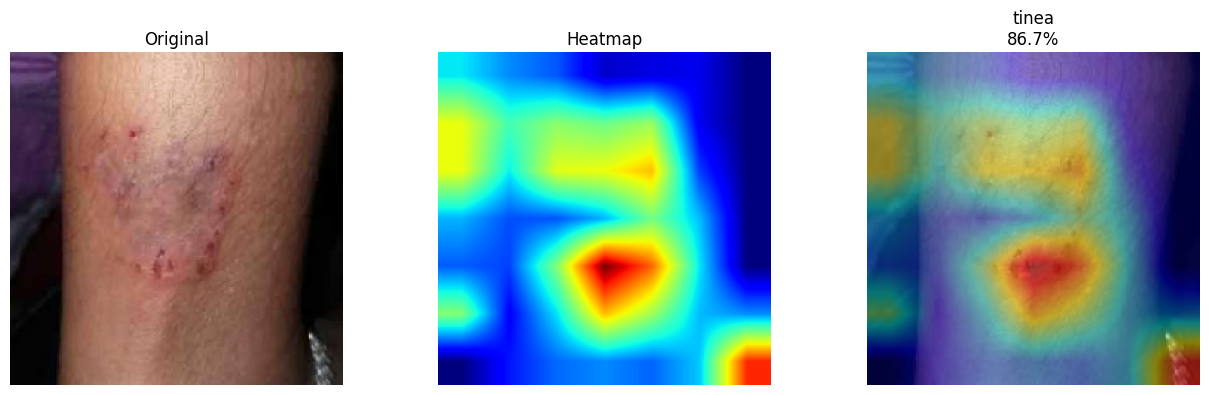

/content/skin-data/test/warts/warts_00116.jpg


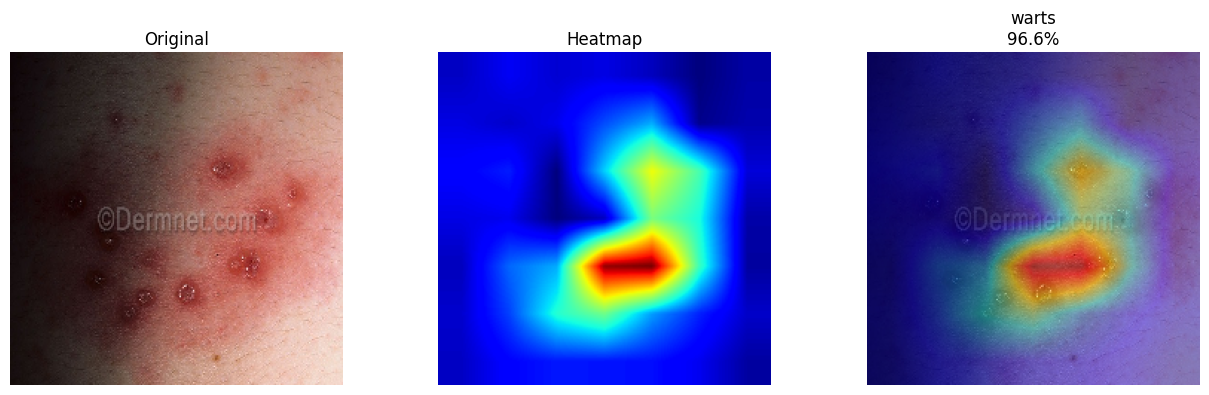

In [63]:
tf.config.run_functions_eagerly(True)

all_test_imgs = []
for cls in CLASS_NAMES:
    all_test_imgs.extend(glob.glob(str(TEST_DIR / cls / "*.jpg")))
    all_test_imgs.extend(glob.glob(str(TEST_DIR / cls / "*.jpeg")))
    all_test_imgs.extend(glob.glob(str(TEST_DIR / cls / "*.png")))

sample_imgs = random.sample(all_test_imgs, min(4, len(all_test_imgs)))
for p in sample_imgs:
    print(p)
    show_gradcam(p, best_model)